In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
plt.rcParams['text.usetex'] = True

In [2]:
def ratio(pop_total, pop_alive, conf):
    if pop_total == 0:
        return 0
    elif conf == 0:
        return 1
    else:
        return min(shell(pop_total, conf) / pop_alive, 1)
    
def shell(pop_total, conf):
    return pop_total - 4/3*np.pi * (core(pop_total, conf))**3
                                                   
def core(pop_total, conf):
    return max((3/4*(pop_total)/np.pi)**(1/3) - 1/conf, 0)

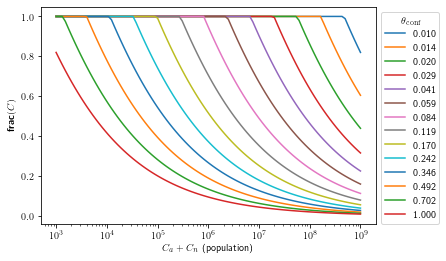

In [3]:
# log scaled array from 0.01 to 1.0 with 16 steps
conf = np.logspace(np.log10(0.01), np.log10(1.0), 14)

# log scaled array from 1000 to 10^9 with 100 steps
pop = np.logspace(3, 9, 100)

# Plot
plt.xscale('log')
plt.xlabel('$C_a + C_n$ (population)')
plt.ylabel(r'$\textbf{frac}(C)$')
for con in conf:
    plt.plot(pop, np.array([ratio(p, p / 2, con) for p in pop]))

# create an artist for the legend
legend_elements = ['{:.3f}'.format(c) for c in conf]

# plot legend from the artist outside of the plot with anchor top right and text "confinement"
plt.legend(legend_elements, loc='upper left', title='$\\theta_{\\rm{conf}}$',  bbox_to_anchor=(1, 1))

# save the plot as a PDF
plt.savefig('figures/confinement.pdf', bbox_inches = 'tight')

# save the plot as a Png
plt.savefig('figures/confinement.png', bbox_inches = 'tight')